In [1]:
import pandas as pd

In [4]:
# 📂 Load dataset
df = pd.read_csv('/Users/nikki/GithubRepo/predictive_maintenance/data/predictive_maintenance.csv')
df.shape

(10000, 10)

In [8]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [15]:
display(df['Target'].value_counts())
display(df['Failure Type'].value_counts())
display(df[df['Failure Type'] != 'No Failure']['Target'].value_counts())
display(df['Type'].value_counts())
display(df[df['Failure Type'] != 'No Failure']['Type'].value_counts())

Target
0    9661
1     339
Name: count, dtype: int64

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

Target
1    330
0     18
Name: count, dtype: int64

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Type
L    243
M     81
H     24
Name: count, dtype: int64

In [5]:
# 🔍 Dataset overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [7]:
# 🧹 Check missing values
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [16]:
# 🔁 Check duplicates
df.duplicated().sum()

np.int64(0)

/var/folders/rk/xdwcbfh148jdgsrjjv6yy2gh0000gn/T/ipykernel_30830/3587215436.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_encoded.select_dtypes(include=["object", "category"]).columns


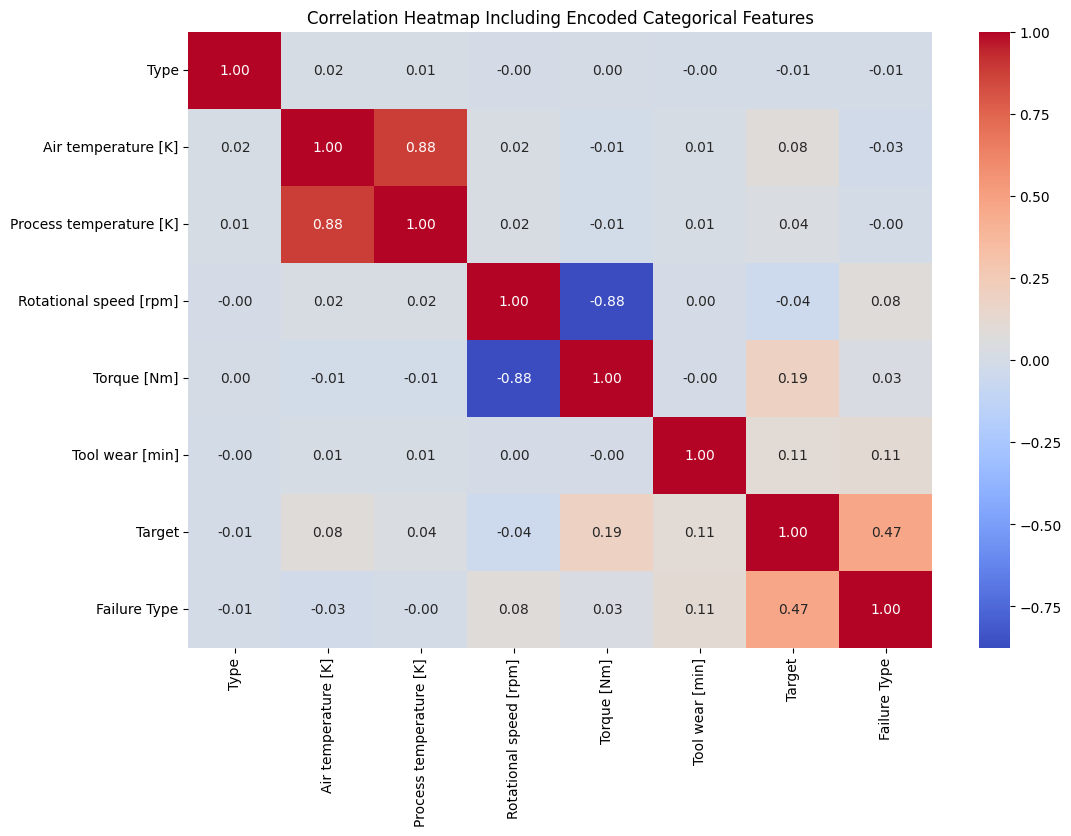

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# drop UDI column and Product ID 
df_encoded.drop(['UDI', 'Product ID'], axis=1, inplace=True)

categorical_cols = df_encoded.select_dtypes(include=["object", "category"]).columns

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

plt.figure(figsize=(12, 8))
sns.heatmap(
    df_encoded.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap Including Encoded Categorical Features")
plt.show()

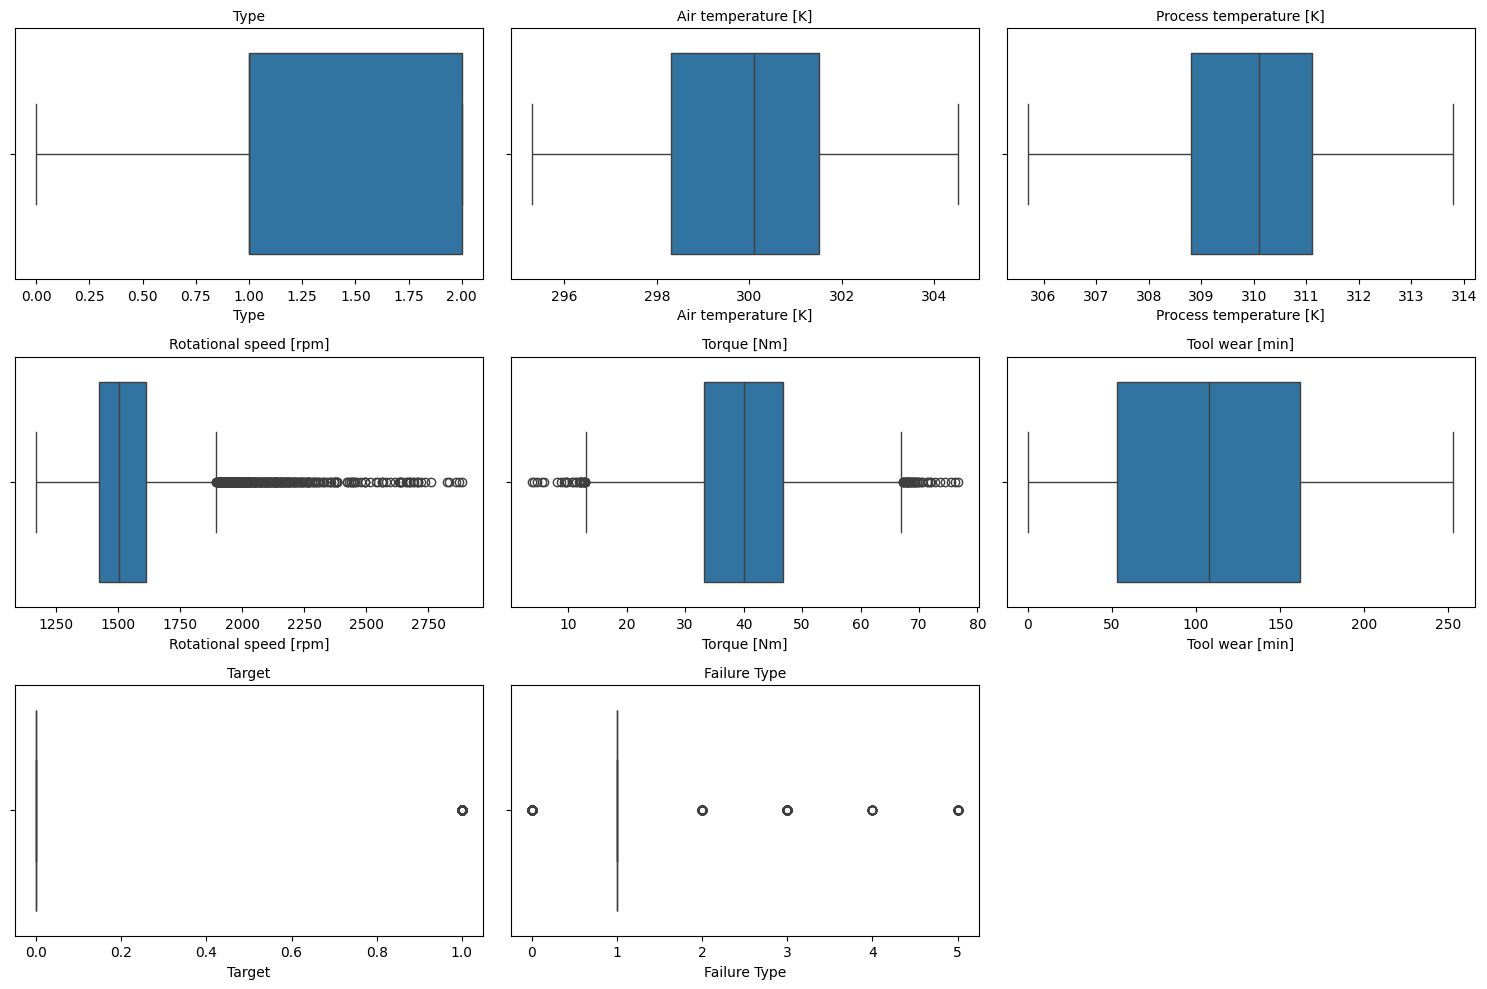

In [19]:
# 📊 Outlier detection using boxplot
import numpy as np

num_cols = df_encoded.select_dtypes(include=np.number).columns
n_cols = 3  # number of plots per row
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_encoded[col])
    plt.title(f'{col}', fontsize=10)

plt.tight_layout()
plt.show()

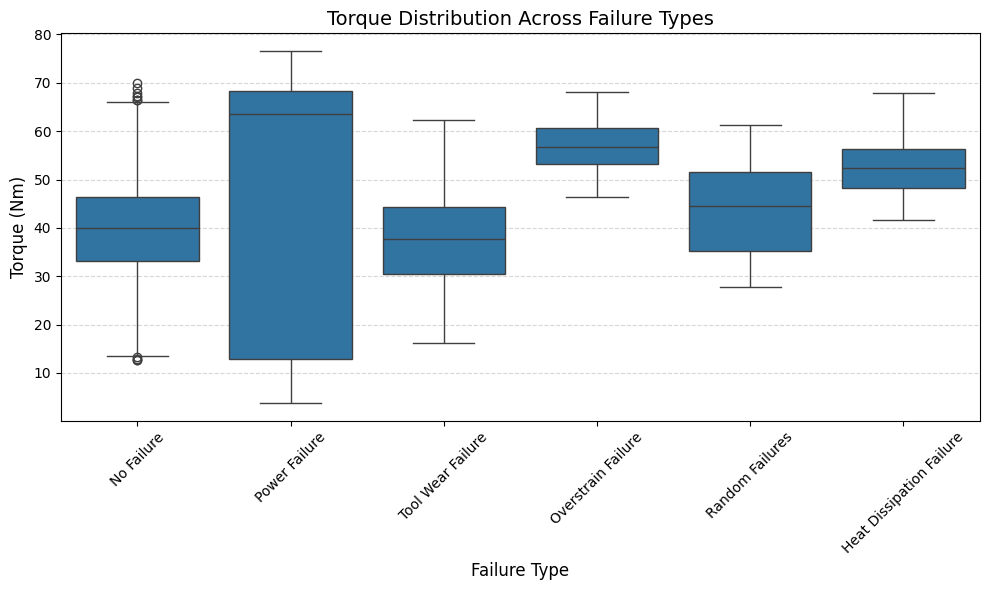

In [23]:


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Failure Type",
    y="Torque [Nm]",
    showfliers=True
)

plt.title("Torque Distribution Across Failure Types", fontsize=14)
plt.xlabel("Failure Type", fontsize=12)
plt.ylabel("Torque (Nm)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

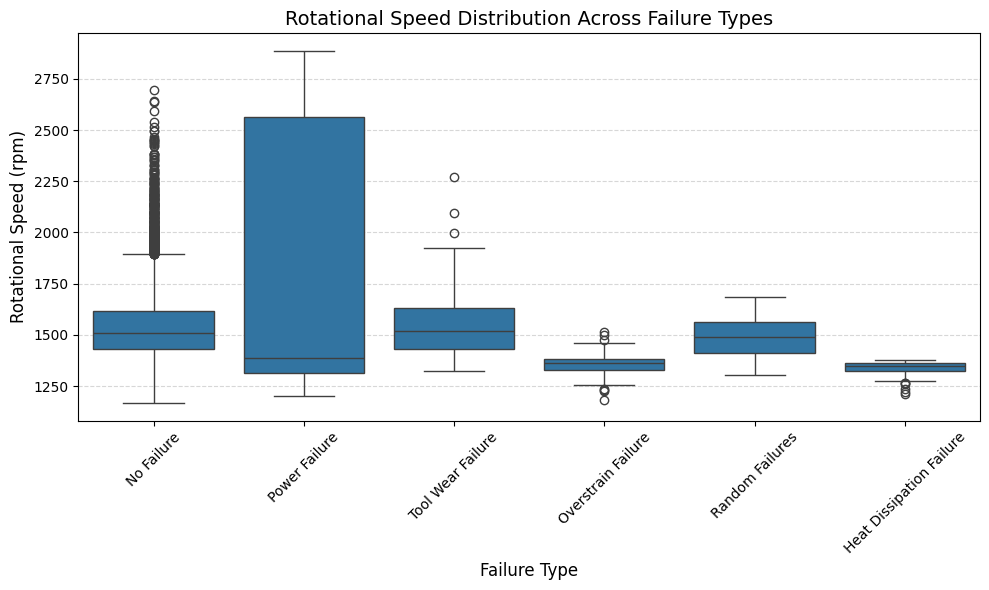

In [25]:


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Failure Type",
    y="Rotational speed [rpm]",
    showfliers=True
)

plt.title("Rotational Speed Distribution Across Failure Types", fontsize=14)
plt.xlabel("Failure Type", fontsize=12)
plt.ylabel("Rotational Speed (rpm)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

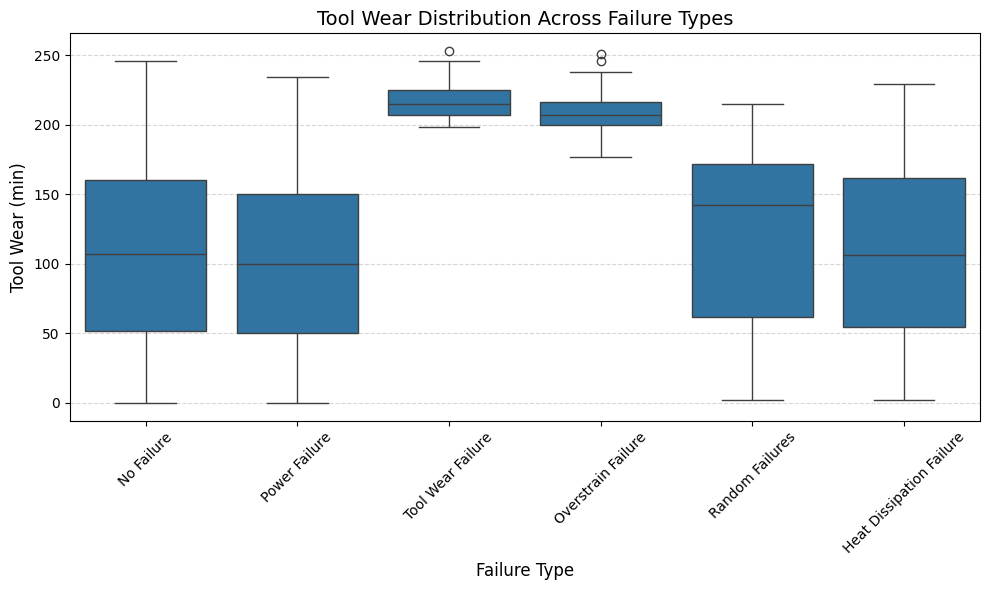

In [28]:


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Failure Type",
    y="Tool wear [min]",
    showfliers=True
)

plt.title("Tool Wear Distribution Across Failure Types", fontsize=14)
plt.xlabel("Failure Type", fontsize=12)
plt.ylabel("Tool Wear (min)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

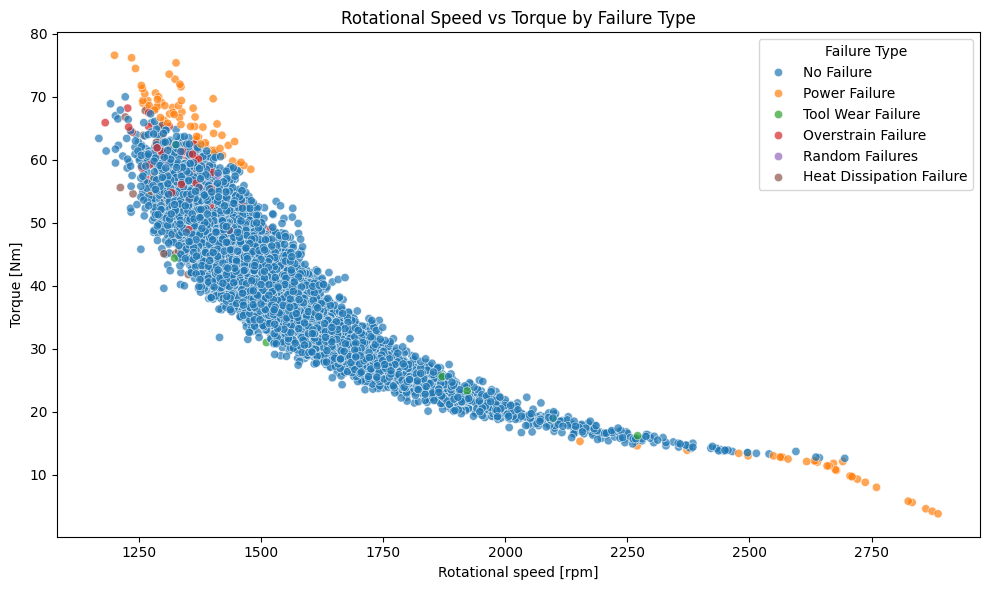

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    hue="Failure Type",
    alpha=0.7
)

plt.title("Rotational Speed vs Torque by Failure Type")
plt.tight_layout()
plt.show()

In [34]:
contradictions = df[
    ((df['Target'] == 1) & (df['Failure Type'] == 'No Failure')) |
    ((df['Target'] == 0) & (df['Failure Type'] != 'No Failure'))
]

contradictions.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
1221,1222,M16081,M,297.0,308.3,1399,46.4,132,0,Random Failures
1302,1303,L48482,L,298.6,309.8,1505,45.7,144,0,Random Failures
1437,1438,H30851,H,298.8,309.9,1439,45.2,40,1,No Failure
1748,1749,H31162,H,298.4,307.7,1626,31.1,166,0,Random Failures
2072,2073,L49252,L,299.6,309.5,1570,35.5,189,0,Random Failures


In [35]:
contradictions.groupby(['Target', 'Failure Type']).size()

Target  Failure Type   
0       Random Failures    18
1       No Failure          9
dtype: int64